# Quality Check
Inspect the per-language quality metrics produced by `quality_check.py`.

## Metric Definitions

Each word-frequency CSV is analysed for the following quality signals:

| Metric | Description |
|--------|-------------|
| **foreign_script_pct** | % of word types whose dominant Unicode script differs from the expected script (declared in filename). |
| **long_outlier_pct** | % of word types longer than the boxplot upper fence: $Q_3 + 3 \cdot IQR$ computed over all word lengths. Catches run-together sentences, URLs, etc. |
| **top20_long_pct** | % of the 20 most-frequent types that are length outliers within those 20, using a tighter fence: $Q_3 + 1.5 \cdot IQR$. |
| **punct_char_pct** | Share of known punctuation characters out of all characters (frequency-weighted). Punctuation set: ``".,?!;:/\@#$%^&*~`<>|+=_()[]{}`` |
| **program_pct** | % of word types that look like programming/web artifacts (URLs, email-like `@`, braces, backslash paths, multiple dots/commas). |
| **corrupted_pct** | Union of long_outlier ∨ foreign_script ∨ program_artifact (each word counted at most once). Punctuation is excluded. |
| **corrupted_freq_pct** | Same union as above, but weighted by word frequency: $\frac{\sum freq_{\text{corrupted}}}{\sum freq_{\text{all}}} \times 100$. |
| **eng_stopwords** | Count of 15 English function words (the, with, there, that, will, which, after, would, people, other, where, years, because, against, however) present in the dataset. Hardcoded to 0 for English. |

### Outlier detection (boxplot method)

Word lengths are sorted and quartiles computed via linear interpolation:
$$\text{upper fence} = Q_3 + k \cdot (Q_3 - Q_1)$$

- **All words**: $k = 3.0$ (very conservative — only extreme outliers)
- **Top-20 frequent words**: $k = 1.5$ (standard Tukey fence — tighter check on high-frequency types)

In [1]:

import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parents[2]
quality = pd.read_csv(ROOT / "results" / "1_process" / "3_truncate" / "quality.csv")
overview = pd.read_csv(ROOT / "results" / "1_process" / "2_aggregate" / "language_overview.csv")

# Map iso code -> full language name, script name
lang_map = overview.set_index("iso_code")["name"].to_dict()
script_map = overview.set_index("iso_code")["primary_script"].to_dict()
quality["language_name"] = quality["language"].map(lang_map)
quality["script_name"] = quality["language"].map(script_map)

print(quality.columns.tolist())


['file', 'language', 'script', 'foreign_script_pct', 'long_outlier_pct', 'top20_long_pct', 'punct_char_pct', 'program_pct', 'corrupted_pct', 'corrupted_freq_pct', 'eng_stopwords', 'long_threshold', 'top20_threshold', 'total_types', 'total_frequency', 'language_name', 'script_name']


In [2]:

# Normalize each metric to 0..1 and sum into quality_score
metric_cols = ["foreign_script_pct", "long_outlier_pct", "punct_char_pct", "program_pct", "eng_stopwords"]
for col in metric_cols:
    mx = quality[col].max()
    quality[col + "_norm"] = quality[col] / mx if mx > 0 else 0.0

norm_cols = [c + "_norm" for c in metric_cols]
quality["quality_score"] = quality[norm_cols].sum(axis=1)

show_cols = ["language_name", "script_name"] + metric_cols + ["corrupted_pct", "quality_score"]
quality.sort_values("quality_score", ascending=False)[show_cols].head(20)


,language_name,script_name,foreign_script_pct,long_outlier_pct,punct_char_pct,program_pct,eng_stopwords,corrupted_pct,quality_score
86,Luxembourgish,Latin,0.6049,5.9060,2.8690,5.3517,15,7.4564,3.827096
95,Maltese,Latin,0.3127,1.1058,2.8606,6.8315,15,7.4638,3.206901
79,Korean,Hangul,12.3159,3.7183,0.4008,0.3623,15,13.5278,2.712256
76,Central Khmer,Khmer,12.6174,1.2277,0.3336,0.8623,15,13.7428,2.362103
62,Armenian,Armenian,13.8390,0.0160,0.1368,0.0846,15,13.8434,2.062775
176,Zulu,Latin,0.2103,4.6611,0.3920,0.8102,15,5.3154,2.059641
139,Somali,Latin,0.5298,2.2086,0.9252,2.0308,15,3.2077,2.031993
100,Burmese,Myanmar,2.9206,2.5411,0.3286,1.6777,15,6.7154,2.001416
6,Egyptian Arabic,Arabic,11.4338,0.7142,0.0716,0.6959,11,11.7917,1.807285
174,Cantonese,Han,8.4422,2.2385,0.0012,0.0027,12,8.4594,1.789864


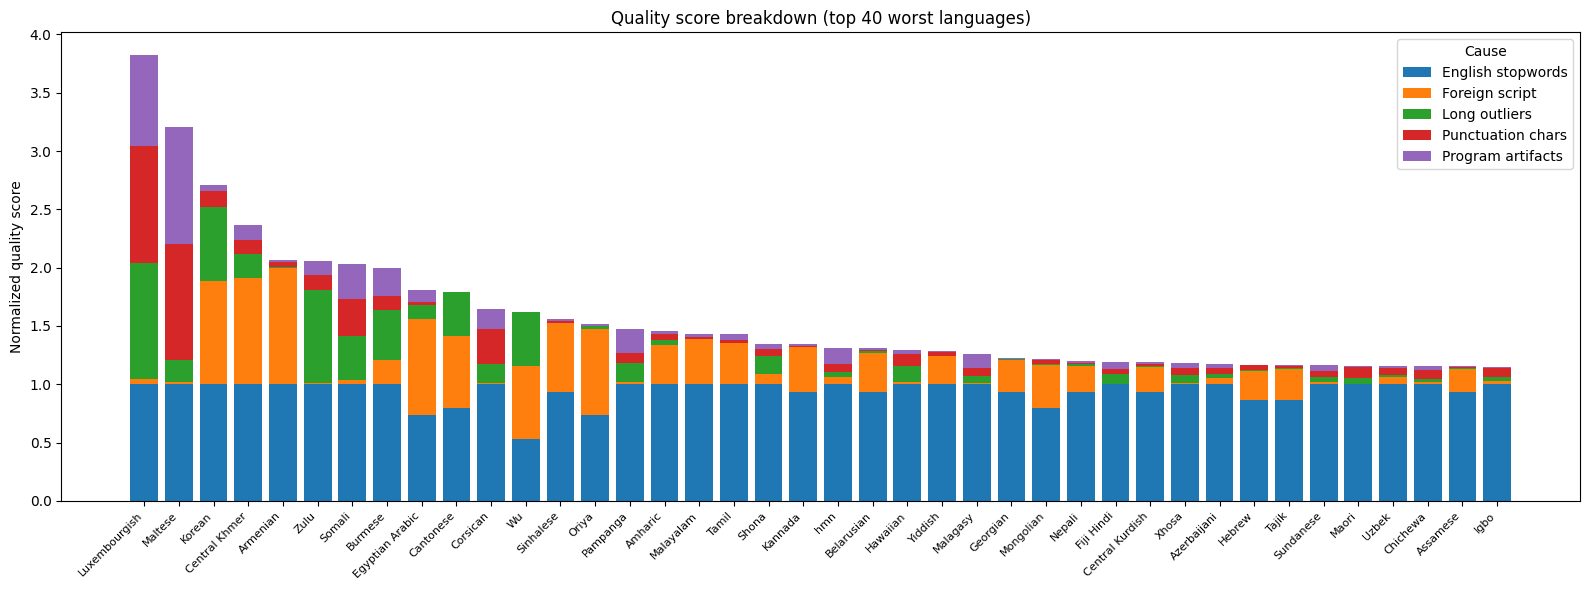

In [3]:
import matplotlib.pyplot as plt
import numpy as np

norm_cols = [c + "_norm" for c in metric_cols]
labels = {
    "foreign_script_pct_norm": "Foreign script",
    "long_outlier_pct_norm": "Long outliers",
    "punct_char_pct_norm": "Punctuation chars",
    "program_pct_norm": "Program artifacts",
    "eng_stopwords_norm": "English stopwords",
}

# Sort languages by total quality_score descending
top = quality.sort_values("quality_score", ascending=False).head(40).copy()
top["label"] = top["language_name"].fillna(top["language"])

# Order the stacked categories: biggest cause at bottom, smallest at top
cause_totals = {c: top[c].sum() for c in norm_cols}
ordered_cols = sorted(cause_totals, key=cause_totals.get, reverse=True)

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(top))
bottom = np.zeros(len(top))

for col in ordered_cols:
    vals = top[col].values
    ax.bar(x, vals, bottom=bottom, label=labels[col])
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(top["label"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Normalized quality score")
ax.set_title("Quality score breakdown (top 40 worst languages)")
ax.legend(title="Cause", loc="upper right")
plt.tight_layout()
plt.show()

graph_export: saved noise.pdf


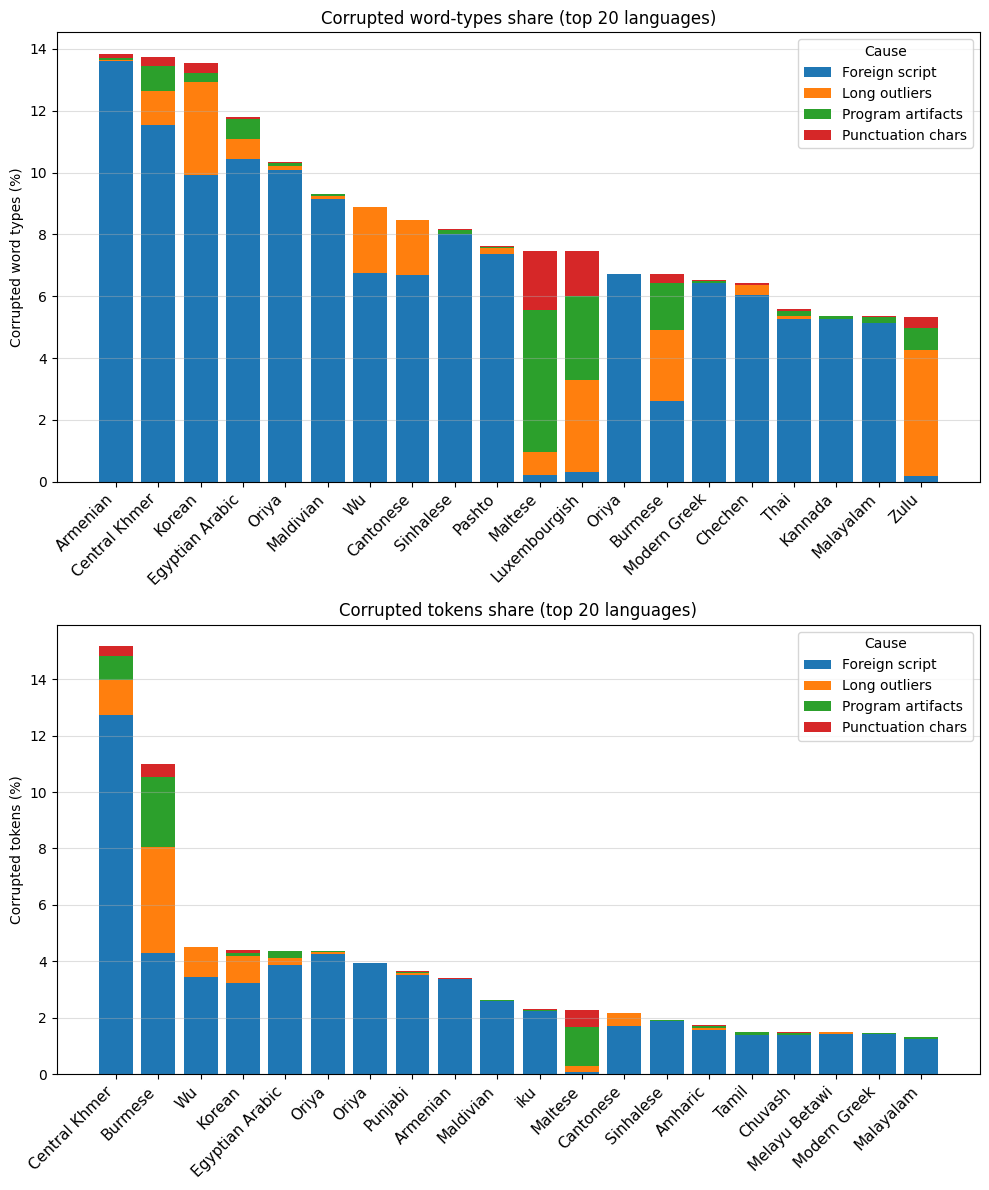

In [4]:
import sys
sys.path.insert(0, str(Path.cwd().parents[2] / "notebooks" / "scripts"))
import graph_export

raw_labels = {
    "foreign_script_pct": "Foreign script",
    "long_outlier_pct": "Long outliers",
    "punct_char_pct": "Punctuation chars",
    "program_pct": "Program artifacts",
}
cause_cols = list(raw_labels.keys())

fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharey=False)

# --- Top: by corrupted_pct (word types) ---
top_raw = quality.sort_values("corrupted_pct", ascending=False).head(20).copy()
top_raw["label"] = top_raw["language_name"].fillna(top_raw["language"])

raw_sum = top_raw[cause_cols].sum(axis=1).replace(0, 1)
for col in cause_cols:
    top_raw[col + "_share"] = top_raw[col] / raw_sum * top_raw["corrupted_pct"]

cause_totals = {c: top_raw[c + "_share"].sum() for c in cause_cols}
raw_ordered = sorted(cause_totals, key=cause_totals.get, reverse=True)

ax = axes[0]
x = np.arange(len(top_raw))
bottom = np.zeros(len(top_raw))
for col in raw_ordered:
    vals = top_raw[col + "_share"].values
    ax.bar(x, vals, bottom=bottom, label=raw_labels[col])
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(top_raw["label"], rotation=45, ha="right", fontsize=11)
ax.set_ylabel("Corrupted word types (%)")
ax.set_title("Corrupted word-types share (top 20 languages)")
ax.legend(title="Cause", loc="upper right")
ax.grid(axis="y", alpha=0.4)

# --- Bottom: by corrupted_freq_pct (frequency-weighted) ---
top_freq = quality.sort_values("corrupted_freq_pct", ascending=False).head(20).copy()
top_freq["label"] = top_freq["language_name"].fillna(top_freq["language"])

freq_sum = top_freq[cause_cols].sum(axis=1).replace(0, 1)
for col in cause_cols:
    top_freq[col + "_share"] = top_freq[col] / freq_sum * top_freq["corrupted_freq_pct"]

freq_cause_totals = {c: top_freq[c + "_share"].sum() for c in cause_cols}
freq_ordered = sorted(freq_cause_totals, key=freq_cause_totals.get, reverse=True)

ax = axes[1]
x = np.arange(len(top_freq))
bottom = np.zeros(len(top_freq))
for col in freq_ordered:
    vals = top_freq[col + "_share"].values
    ax.bar(x, vals, bottom=bottom, label=raw_labels[col])
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(top_freq["label"], rotation=45, ha="right", fontsize=11)
ax.set_ylabel("Corrupted tokens (%)")
ax.set_title("Corrupted tokens share (top 20 languages)")
ax.legend(title="Cause", loc="upper right")
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
graph_export.save("noise", fig)
plt.show()